# NB15 — Forecast Monitoring & Drift Strategy

## Objective

Previous notebooks built the forecasting system and introduced:

- model benchmarking
- business-aware evaluation
- forecast trust scoring
- operational decision logic

NB15 adds the final production layer.

The goal is not to improve forecast accuracy.

The goal is to define how the forecasting system should be monitored after deployment.

This notebook introduces:

- forecast monitoring signals
- drift detection rules
- alert conditions
- retraining triggers

NB15 defines how to detect when forecast quality is degrading
and when intervention is required.

This is not a modeling notebook.

This is a production monitoring notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

In [2]:
ARTIFACTS_DIR = Path("../artifacts/nb15_forecast_monitoring")
NB14_DIR = Path("../artifacts/nb14_forecast_trust_framework")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

NB14_PATH = NB14_DIR / "nb14_forecast_trust_scored.csv"

print("Setup OK")
print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Setup OK
Artifacts dir: /home/donatocorbacio/projects/store-sales-project/artifacts/nb15_forecast_monitoring


## Load Trust-Scored Forecasts

NB15 uses the trust-scored forecast outputs generated in NB14.

The objective is to monitor:

- trust degradation
- error drift
- segment degradation
- operational instability

This notebook evaluates how forecast reliability should be monitored over time.

In [3]:
df = pd.read_csv(NB14_PATH, parse_dates=["date"])

print("Loaded shape:", df.shape)
display(df.head())

Loaded shape: (49896, 25)


,fold,date,store_nbr,family,sales,prediction,onpromotion,error,abs_error,pct_error,...,sales_segment,sales_risk_score,promo_risk_score,underforecast_risk_score,impact_risk_score,error_risk_score,risk_score,trust_score,trust_tier,decision_action
0,2,2017-07-19,1,0,7.0,10.533682,0,-3.533682,3.533682,0.504812,...,mid,0.3,0.0,0.0,0.000042,0.504812,0.196450,0.803550,Safe,Use Forecast
1,2,2017-07-20,1,0,4.0,8.521036,0,-4.521036,4.521036,1.130259,...,low,0.1,0.0,0.0,0.000031,1.000000,0.315005,0.684995,Review,Manual Review
2,2,2017-07-21,1,0,10.0,9.044243,0,0.955757,0.955757,0.095576,...,mid,0.3,0.0,1.0,0.000016,0.095576,0.273675,0.726325,Safe,Use Forecast
3,2,2017-07-22,1,0,8.0,0.000000,0,8.000000,8.000000,1.000000,...,mid,0.3,0.0,1.0,0.000108,1.000000,0.545016,0.454984,Review,Manual Review
4,2,2017-07-23,1,0,0.0,0.000000,0,0.000000,0.000000,NaN,...,low,0.1,0.0,0.0,0.000000,0.000000,0.015000,0.985000,Safe,Use Forecast


## Build Monitoring Frame

Monitoring requires stable operational signals.

We aggregate prediction behavior over time to detect degradation patterns.

In [4]:
monitor = (
    df.groupby("date")
    .agg(
        mean_trust=("trust_score", "mean"),
        risky_share=("trust_tier", lambda x: (x == "Risky").mean()),
        review_share=("trust_tier", lambda x: (x == "Review").mean()),
        mean_abs_error=("abs_error", "mean"),
        mean_pct_error=("pct_error", "mean"),
        underforecast_rate=("underforecast", "mean"),
        promo_risky_share=("promo_flag", lambda x: ((df.loc[x.index, "promo_flag"] == 1) & (df.loc[x.index, "trust_tier"] == "Risky")).mean())
    )
    .reset_index()
)

display(monitor.head())

,date,mean_trust,risky_share,review_share,mean_abs_error,mean_pct_error,underforecast_rate,promo_risky_share
0,2017-07-19,0.666598,0.140853,0.494949,43.525382,0.411084,0.459596,0.140292
1,2017-07-20,0.679579,0.154882,0.456790,42.957904,0.584667,0.372615,0.154321
2,2017-07-21,0.667122,0.154321,0.492705,49.481917,0.438104,0.359708,0.153760
3,2017-07-22,0.641218,0.156566,0.519641,52.270526,0.339052,0.524130,0.156566
4,2017-07-23,0.658713,0.156004,0.495511,62.148844,0.457628,0.407969,0.155443


## Define Monitoring Baselines

Baseline monitoring thresholds are estimated from observed forecast behavior.

These thresholds define normal operating conditions.

In [5]:
baseline = {
    "mean_trust_min": monitor["mean_trust"].quantile(0.10),
    "risky_share_max": monitor["risky_share"].quantile(0.90),
    "mean_abs_error_max": monitor["mean_abs_error"].quantile(0.90),
    "underforecast_rate_max": monitor["underforecast_rate"].quantile(0.90),
    "promo_risky_share_max": monitor["promo_risky_share"].quantile(0.90),
}

baseline_df = pd.DataFrame(
    {"metric": baseline.keys(), "threshold": baseline.values()}
)

display(baseline_df)

,metric,threshold
0,mean_trust_min,0.621228
1,risky_share_max,0.190123
2,mean_abs_error_max,72.585992
3,underforecast_rate_max,0.531594
4,promo_risky_share_max,0.189169


## Detect Drift Signals

Drift signals identify abnormal forecast behavior relative to normal operating conditions.

In [6]:
monitor["trust_drift"] = monitor["mean_trust"] < baseline["mean_trust_min"]
monitor["risk_drift"] = monitor["risky_share"] > baseline["risky_share_max"]
monitor["error_drift"] = monitor["mean_abs_error"] > baseline["mean_abs_error_max"]
monitor["underforecast_drift"] = monitor["underforecast_rate"] > baseline["underforecast_rate_max"]
monitor["promo_drift"] = monitor["promo_risky_share"] > baseline["promo_risky_share_max"]

display(monitor.head())

,date,mean_trust,risky_share,review_share,mean_abs_error,mean_pct_error,underforecast_rate,promo_risky_share,trust_drift,risk_drift,error_drift,underforecast_drift,promo_drift
0,2017-07-19,0.666598,0.140853,0.494949,43.525382,0.411084,0.459596,0.140292,False,False,False,False,False
1,2017-07-20,0.679579,0.154882,0.456790,42.957904,0.584667,0.372615,0.154321,False,False,False,False,False
2,2017-07-21,0.667122,0.154321,0.492705,49.481917,0.438104,0.359708,0.153760,False,False,False,False,False
3,2017-07-22,0.641218,0.156566,0.519641,52.270526,0.339052,0.524130,0.156566,False,False,False,False,False
4,2017-07-23,0.658713,0.156004,0.495511,62.148844,0.457628,0.407969,0.155443,False,False,False,False,False


## Build Alert Layer

Multiple drift signals are combined into operational alerts.

In [7]:
drift_cols = [
    "trust_drift",
    "risk_drift",
    "error_drift",
    "underforecast_drift",
    "promo_drift"
]

monitor["drift_score"] = monitor[drift_cols].sum(axis=1)

def assign_alert_level(score):
    if score >= 3:
        return "Critical"
    elif score >= 2:
        return "Warning"
    elif score >= 1:
        return "Watch"
    return "Stable"

monitor["alert_level"] = monitor["drift_score"].apply(assign_alert_level)

display(monitor["alert_level"].value_counts())

alert_level
Stable      21
Warning      3
Critical     2
Watch        2
Name: count, dtype: int64

## Define Operational Actions

Alert levels are translated into monitoring actions.

In [8]:
alert_action_map = {
    "Stable": "No Action",
    "Watch": "Monitor Closely",
    "Warning": "Investigate",
    "Critical": "Trigger Retraining Review"
}

monitor["monitoring_action"] = monitor["alert_level"].map(alert_action_map)

display(monitor[["date", "alert_level", "monitoring_action"]].head())

,date,alert_level,monitoring_action
0,2017-07-19,Stable,No Action
1,2017-07-20,Stable,No Action
2,2017-07-21,Stable,No Action
3,2017-07-22,Stable,No Action
4,2017-07-23,Stable,No Action


## Monitoring Distribution

Inspect monitoring states across the observed time period.

,alert_level,pct
0,Stable,75.00
1,Warning,10.71
2,Critical,7.14
3,Watch,7.14


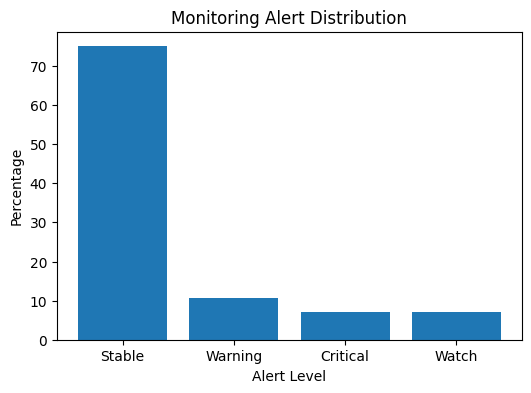

In [9]:
alert_dist = (
    monitor["alert_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

alert_dist.columns = ["alert_level", "pct"]
display(alert_dist)

plt.figure(figsize=(6,4))
plt.bar(alert_dist["alert_level"], alert_dist["pct"])
plt.title("Monitoring Alert Distribution")
plt.ylabel("Percentage")
plt.xlabel("Alert Level")
plt.show()

## Drift Timeline

Visualize trust degradation over time.

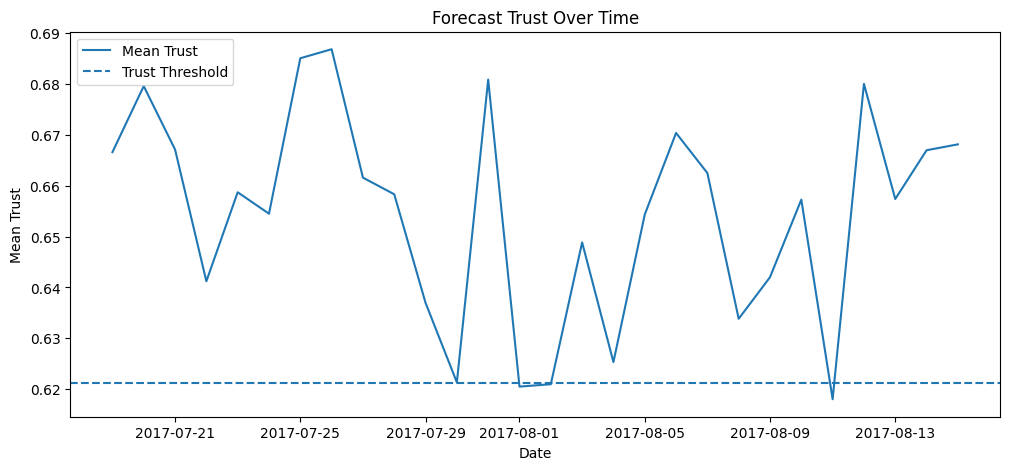

In [10]:
plt.figure(figsize=(12,5))
plt.plot(monitor["date"], monitor["mean_trust"], label="Mean Trust")
plt.axhline(baseline["mean_trust_min"], linestyle="--", label="Trust Threshold")
plt.title("Forecast Trust Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Trust")
plt.legend()
plt.show()

## Alert Summary

Summarize monitoring behavior and intervention frequency.

In [11]:
alert_summary = (
    monitor["monitoring_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

alert_summary.columns = ["monitoring_action", "pct"]

display(alert_summary)

,monitoring_action,pct
0,No Action,75.00
1,Investigate,10.71
2,Trigger Retraining Review,7.14
3,Monitor Closely,7.14


## Save Artifacts

Persist monitoring outputs for downstream operational use.

In [12]:
monitor.to_csv(ARTIFACTS_DIR / "nb15_monitoring_signals.csv", index=False)
baseline_df.to_csv(ARTIFACTS_DIR / "nb15_monitoring_thresholds.csv", index=False)
alert_summary.to_csv(ARTIFACTS_DIR / "nb15_alert_summary.csv", index=False)

print("Saved artifacts to:", ARTIFACTS_DIR.resolve())

Saved artifacts to: /home/donatocorbacio/projects/store-sales-project/artifacts/nb15_forecast_monitoring


## Final Takeaways

NB15 closes the forecasting pipeline by defining how forecast quality should be monitored after deployment.

Previous notebooks answered:

- how accurate the forecast is
- where forecast failures concentrate
- when the forecast should be trusted

NB15 answers the final production question:

- how do we detect when forecast quality is degrading?

This notebook introduces the final operational layer:

- monitoring
- alerting
- retraining governance

This closes the forecasting system as a production-ready ML workflow.